# 02 - Baseline Models

This notebook trains and evaluates baseline deep learning models for global solar radiation forecasting.

Models included:
- MLP
- CNN1D
- LSTM
- GRU

The notebook performs:
- training
- validation
- testing
- multiple seeds
- metrics calculation
- result storage
- prediction visualization

In [1]:
import os
import json
import time
import random
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Flatten,
    Conv1D,
    MaxPooling1D,
    LSTM,
    GRU,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

I0000 00:00:1778964097.086569     324 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778964097.111401     324 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778964097.656264     324 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

print("Available GPUs:", gpus)

TensorFlow version: 2.21.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

In [4]:
BASE_DIR = "/home/jovyan/work"

OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")
ARRAYS_DIR = os.path.join(OUTPUT_DIR, "arrays")
MODELS_DIR = os.path.join(OUTPUT_DIR, "models")
RESULTS_DIR = os.path.join(OUTPUT_DIR, "results")
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")
SCALERS_DIR = os.path.join(OUTPUT_DIR, "scalers")

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

In [5]:
config_path = os.path.join(OUTPUT_DIR, "preprocessing_config.json")

with open(config_path, "r") as f:
    CONFIG = json.load(f)

CONFIG

{'file_name': 'EMA--OMUAQ_Table1.txt',
 'timestamp_column': 'TIMESTAMP',
 'target': 'SolRad_Avg',
 'window_size': 12,
 'horizon': 6,
 'train_ratio': 0.7,
 'val_ratio': 0.15,
 'test_ratio': 0.15,
 'irradiance_threshold': 50,
 'features': ['TempAir_Avg',
  'HumRel',
  'PreBar_Avg',
  'VelVto_S_WVT',
  'DirVto_D1_WVT',
  'DirVto_SD1_WVT',
  'hour',
  'dayofyear',
  'month'],
 'n_features': 9,
 'n_samples': 28034,
 'train_size': 19623,
 'val_size': 4205,
 'test_size': 4206}

In [6]:
X_train = np.load(os.path.join(ARRAYS_DIR, "X_train.npy"))
y_train = np.load(os.path.join(ARRAYS_DIR, "y_train.npy"))

X_val = np.load(os.path.join(ARRAYS_DIR, "X_val.npy"))
y_val = np.load(os.path.join(ARRAYS_DIR, "y_val.npy"))

X_test = np.load(os.path.join(ARRAYS_DIR, "X_test.npy"))
y_test = np.load(os.path.join(ARRAYS_DIR, "y_test.npy"))

timestamps_test = np.load(
    os.path.join(ARRAYS_DIR, "timestamps_test.npy"),
    allow_pickle=True
)

daylight_test = np.load(
    os.path.join(ARRAYS_DIR, "daylight_test.npy")
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (19623, 12, 9)
y_train: (19623, 1)
X_val: (4205, 12, 9)
y_val: (4205, 1)
X_test: (4206, 12, 9)
y_test: (4206, 1)


In [7]:
scaler_y = joblib.load(
    os.path.join(SCALERS_DIR, "scaler_y.pkl")
)

In [8]:
WINDOW_SIZE = X_train.shape[1]
N_FEATURES = X_train.shape[2]

EPOCHS = 100
BATCH_SIZE = 32
LEARNING_RATE = 0.001

SEEDS = [0, 1, 2, 3, 4]

print("Window size:", WINDOW_SIZE)
print("Features:", N_FEATURES)

Window size: 12
Features: 9


In [9]:
def calculate_metrics(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [10]:
def calculate_daylight_metrics(
    y_true,
    y_pred,
    daylight_mask
):

    y_true_day = y_true[daylight_mask]
    y_pred_day = y_pred[daylight_mask]

    return calculate_metrics(
        y_true_day,
        y_pred_day
    )

In [11]:
def inverse_transform(data, scaler):
    return scaler.inverse_transform(data)

In [12]:
def build_mlp(
    input_shape,
    learning_rate=0.001
):

    model = Sequential([

        Flatten(input_shape=input_shape),

        Dense(128, activation="relu"),
        Dropout(0.2),

        Dense(64, activation="relu"),
        Dropout(0.2),

        Dense(32, activation="relu"),

        Dense(1)

    ])

    model.compile(
        optimizer=Adam(
            learning_rate=learning_rate
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model

In [13]:
def build_cnn1d(
    input_shape,
    learning_rate=0.001
):

    model = Sequential([

        Conv1D(
            filters=64,
            kernel_size=3,
            activation="relu",
            input_shape=input_shape
        ),

        MaxPooling1D(pool_size=2),

        Conv1D(
            filters=32,
            kernel_size=3,
            activation="relu"
        ),

        Flatten(),

        Dense(64, activation="relu"),
        Dropout(0.2),

        Dense(32, activation="relu"),

        Dense(1)

    ])

    model.compile(
        optimizer=Adam(
            learning_rate=learning_rate
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model

In [14]:
def build_lstm(
    input_shape,
    learning_rate=0.001
):

    model = Sequential([

        LSTM(
            64,
            return_sequences=True,
            input_shape=input_shape
        ),

        Dropout(0.2),

        LSTM(32),

        Dropout(0.2),

        Dense(32, activation="relu"),

        Dense(1)

    ])

    model.compile(
        optimizer=Adam(
            learning_rate=learning_rate
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model

In [15]:
def build_gru(
    input_shape,
    learning_rate=0.001
):

    model = Sequential([

        GRU(
            64,
            return_sequences=True,
            input_shape=input_shape
        ),

        Dropout(0.2),

        GRU(32),

        Dropout(0.2),

        Dense(32, activation="relu"),

        Dense(1)

    ])

    model.compile(
        optimizer=Adam(
            learning_rate=learning_rate
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model

In [16]:
def train_and_evaluate_model(
    model_name,
    build_function,
    seed
):

    set_seed(seed)

    print(f"\nTraining {model_name} | Seed {seed}")

    model = build_function(
        input_shape=(WINDOW_SIZE, N_FEATURES),
        learning_rate=LEARNING_RATE
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    start_time = time.time()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stopping],
        verbose=1
    )

    training_time = time.time() - start_time

    y_pred_test = model.predict(X_test)

    y_test_inv = inverse_transform(
        y_test,
        scaler_y
    )

    y_pred_test_inv = inverse_transform(
        y_pred_test,
        scaler_y
    )

    overall_metrics = calculate_metrics(
        y_test_inv,
        y_pred_test_inv
    )

    daylight_metrics = calculate_daylight_metrics(
        y_test_inv,
        y_pred_test_inv,
        daylight_test
    )

    result = {

        "Model": model_name,
        "Seed": seed,

        "Test_MAE": overall_metrics["MAE"],
        "Test_RMSE": overall_metrics["RMSE"],
        "Test_R2": overall_metrics["R2"],

        "Daylight_MAE": daylight_metrics["MAE"],
        "Daylight_RMSE": daylight_metrics["RMSE"],
        "Daylight_R2": daylight_metrics["R2"],

        "Training_Time_Seconds": training_time,
        "Epochs": len(history.history["loss"])

    }

    return (
        result,
        history,
        model,
        y_pred_test_inv,
        y_test_inv
    )

In [17]:
models = {
    "MLP": build_mlp,
    "CNN1D": build_cnn1d,
    "LSTM": build_lstm,
    "GRU": build_gru
}

In [18]:
all_results = []

histories = {}
trained_models = {}
predictions = {}

for model_name, build_function in models.items():

    for seed in SEEDS:

        (
            result,
            history,
            model,
            y_pred_test_inv,
            y_test_inv

        ) = train_and_evaluate_model(
            model_name=model_name,
            build_function=build_function,
            seed=seed
        )

        all_results.append(result)

        histories[f"{model_name}_{seed}"] = history

        trained_models[f"{model_name}_{seed}"] = model

        predictions[f"{model_name}_{seed}"] = {
            "y_true": y_test_inv,
            "y_pred": y_pred_test_inv
        }


Training MLP | Seed 0


/opt/venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1778964282.436582     324 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10176 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070, pci bus id: 0000:01:00.0, compute capability: 8.9


Epoch 1/100


I0000 00:00:1778964283.277912     490 service.cc:153] XLA service 0x7f7b58033340 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778964283.277927     490 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4070, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1778964283.289300     490 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778964283.361501     490 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1778964283.383537     490 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1748__.12
I0000 00:00:1778964283.521467     490 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I00

307/614 ━━━━━━━━━━━━━━━━━━━━ 0s 493us/step - loss: 0.0517 - mae: 0.1722

...

614/614 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0173 - mae: 0.0919 - val_loss: 0.0140 - val_mae: 0.0746
Epoch 2/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0064 - mae: 0.0506 - val_loss: 0.0106 - val_mae: 0.0632
Epoch 3/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0053 - mae: 0.0449 - val_loss: 0.0104 - val_mae: 0.0587
Epoch 4/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0050 - mae: 0.0426 - val_loss: 0.0110 - val_mae: 0.0616
Epoch 5/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0046 - mae: 0.0404 - val_loss: 0.0124 - val_mae: 0.0624
Epoch 6/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0043 - mae: 0.0388 - val_loss: 0.0109 - val_mae: 0.0537
Epoch 7/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0039 - mae: 0.0369 - val_loss: 0.0102 - val_mae: 0.0529
Epoch 8/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0038 - mae: 0.0359 - val_loss: 0.0088 - val_mae: 0.0465
Epoch 9/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step 

/opt/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


614/614 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.0200 - mae: 0.0976 - val_loss: 0.0103 - val_mae: 0.0594
Epoch 2/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0067 - mae: 0.0526 - val_loss: 0.0095 - val_mae: 0.0590
Epoch 3/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0057 - mae: 0.0475 - val_loss: 0.0090 - val_mae: 0.0574
Epoch 4/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0051 - mae: 0.0439 - val_loss: 0.0086 - val_mae: 0.0522
Epoch 5/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0048 - mae: 0.0419 - val_loss: 0.0095 - val_mae: 0.0584
Epoch 6/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0044 - mae: 0.0399 - val_loss: 0.0086 - val_mae: 0.0532
Epoch 7/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0040 - mae: 0.0375 - val_loss: 0.0086 - val_mae: 0.0510
Epoch 8/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0040 - mae: 0.0375 - val_loss: 0.0083 - val_mae: 0.0481
Epoch 9/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss:

/opt/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


614/614 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0184 - mae: 0.0964 - val_loss: 0.0133 - val_mae: 0.0660
Epoch 2/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0066 - mae: 0.0527 - val_loss: 0.0127 - val_mae: 0.0651
Epoch 3/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0056 - mae: 0.0471 - val_loss: 0.0108 - val_mae: 0.0640
Epoch 4/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0050 - mae: 0.0432 - val_loss: 0.0091 - val_mae: 0.0554
Epoch 5/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0047 - mae: 0.0420 - val_loss: 0.0101 - val_mae: 0.0575
Epoch 6/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0044 - mae: 0.0401 - val_loss: 0.0106 - val_mae: 0.0605
Epoch 7/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.0042 - mae: 0.0385 - val_loss: 0.0097 - val_mae: 0.0556
Epoch 8/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0039 - mae: 0.0366 - val_loss: 0.0101 - val_mae: 0.0584
Epoch 9/100
614/614 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step

In [19]:
results_df = pd.DataFrame(all_results)

results_df

,Model,Seed,Test_MAE,Test_RMSE,Test_R2,Daylight_MAE,Daylight_RMSE,Daylight_R2,Training_Time_Seconds,Epochs
0,MLP,0,65.665880,113.645421,0.913334,127.945665,159.848603,0.767744,13.806466,21
1,MLP,1,66.528532,115.869645,0.909909,126.497070,162.227761,0.760779,21.904707,44
2,MLP,2,75.782521,122.259362,0.899699,140.049666,171.964127,0.731202,12.035300,23
3,MLP,3,62.642823,109.424723,0.919652,120.569489,153.734586,0.785171,20.891664,41
4,MLP,4,66.673266,113.443079,0.913643,123.137229,159.017096,0.770154,14.908950,27
5,CNN1D,0,79.431200,131.163327,0.884557,154.673577,185.363074,0.687683,17.569271,22
6,CNN1D,1,67.592846,116.246013,0.909323,126.703094,160.409169,0.766112,14.296594,23
7,CNN1D,2,71.975376,125.516337,0.894283,139.564202,177.357899,0.714076,9.786358,15
8,CNN1D,3,72.570301,117.079978,0.908017,136.623480,162.509629,0.759947,13.826030,21
9,CNN1D,4,77.348852,126.408042,0.892776,150.591188,176.771537,0.715963,14.070250,24


In [20]:
results_path = os.path.join(
    RESULTS_DIR,
    "baseline_results.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

print("Saved:", results_path)

Saved: /home/jovyan/work/outputs/results/baseline_results.csv


In [21]:
summary_df = results_df.groupby("Model").agg({
    "Test_MAE": ["mean", "std"],
    "Test_RMSE": ["mean", "std"],
    "Test_R2": ["mean", "std"],
    "Daylight_MAE": ["mean", "std"],
    "Daylight_RMSE": ["mean", "std"],
    "Daylight_R2": ["mean", "std"]
})

summary_df

Test_MAE             Test_RMSE             Test_R2            \
            mean       std        mean       std      mean       std   
Model                                                                  
CNN1D  73.783715  4.681709  123.282739  6.419694  0.897791  0.010608   
GRU    63.765284  4.543839  112.108240  4.164174  0.915570  0.006134   
LSTM   69.569351  5.957919  114.623569  4.595352  0.911723  0.007027   
MLP    67.458604  4.928869  114.928446  4.710934  0.911247  0.007347   

      Daylight_MAE            Daylight_RMSE            Daylight_R2            
              mean        std          mean        std        mean       std  
Model                                                                         
CNN1D   141.631108  11.209182    172.482261  10.645399    0.728756  0.033296  
GRU     117.052837  11.350561    156.011823   6.878480    0.778415  0.019048  
LSTM    115.750315  12.745650    156.484603   8.602835    0.776878  0.024305  
MLP     127.639824   7.511102    161.358434   6.691804    0.763010  0.019883

In [22]:
summary_path = os.path.join(
    RESULTS_DIR,
    "baseline_summary.csv"
)

summary_df.to_csv(summary_path)

print("Saved:", summary_path)

Saved: /home/jovyan/work/outputs/results/baseline_summary.csv


In [23]:
for key, model in trained_models.items():

    model_path = os.path.join(
        MODELS_DIR,
        f"{key}.keras"
    )

    model.save(model_path)

print("Models saved.")

Models saved.


In [25]:
def plot_history(history, title):

    plt.figure(figsize=(10,5))

    plt.plot(
        history.history["loss"],
        label="Train Loss"
    )

    plt.plot(
        history.history["val_loss"],
        label="Validation Loss"
    )

    plt.title(title)

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.legend()
    plt.grid(True)

    plt.show()

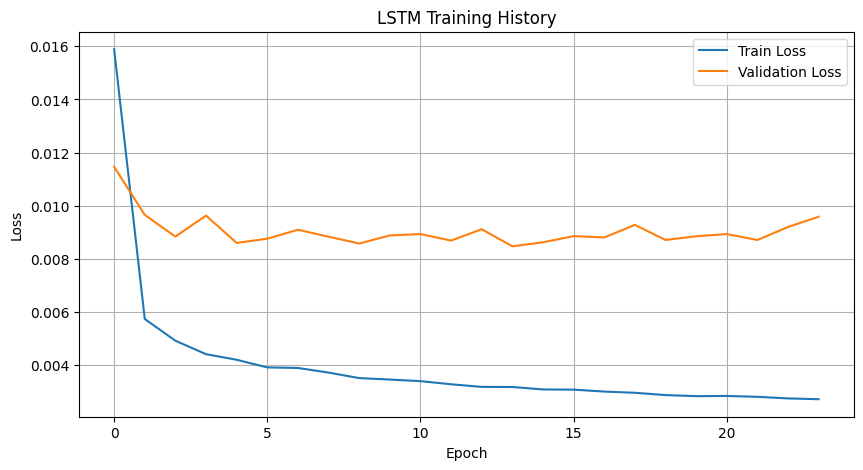

In [26]:
plot_history(
    histories["LSTM_0"],
    "LSTM Training History"
)

In [27]:
def plot_predictions(
    y_true,
    y_pred,
    title,
    n_points=300
):

    plt.figure(figsize=(15,5))

    plt.plot(
        y_true[:n_points],
        label="Real"
    )

    plt.plot(
        y_pred[:n_points],
        label="Predicted"
    )

    plt.title(title)

    plt.xlabel("Time")
    plt.ylabel("Solar Radiation")

    plt.legend()
    plt.grid(True)

    plt.show()

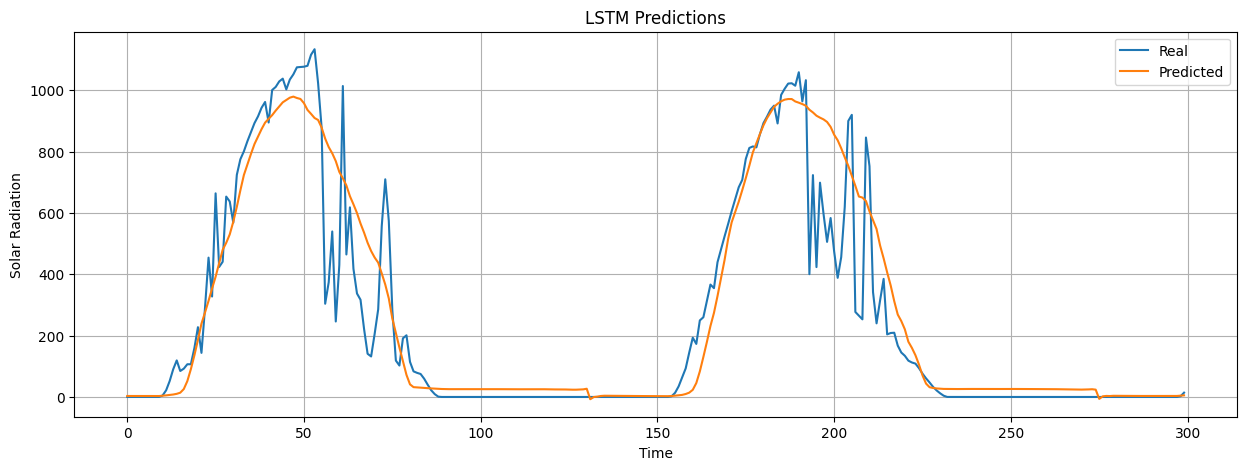

In [28]:
plot_predictions(
    predictions["LSTM_0"]["y_true"],
    predictions["LSTM_0"]["y_pred"],
    "LSTM Predictions"
)

<Figure size 1000x500 with 0 Axes>

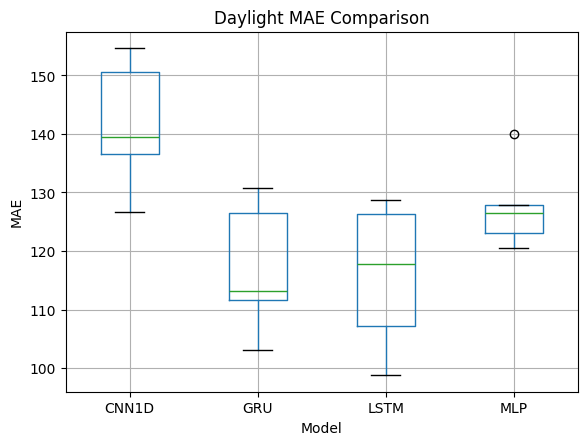

In [29]:
plt.figure(figsize=(10,5))

results_df.boxplot(
    column="Daylight_MAE",
    by="Model"
)

plt.title("Daylight MAE Comparison")
plt.suptitle("")

plt.ylabel("MAE")

plt.grid(True)

plt.show()

In [31]:
best_result = results_df.sort_values(
    "Daylight_MAE"
).iloc[0]

best_result
best_model_path = os.path.join(
    RESULTS_DIR,
    "best_model.json"
)

with open(best_model_path, "w") as f:
    json.dump(
        best_result.to_dict(),
        f,
        indent=4,
        default=str
    )

print("Saved:", best_model_path)

Saved: /home/jovyan/work/outputs/results/best_model.json
